# Exploratory Analysis of Gym Workout Data

## import libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import preprocessing
%matplotlib inline
import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## Read in Data

In [2]:
df=pd.read_csv('/kaggle/input/gym-members-exercise-dataset/gym_members_exercise_tracking.csv')
df.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [3]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the Gender column
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# Apply Label Encoding to the Workout_Type column
df['Workout_Type_Encoded'] = le.fit_transform(df['Workout_Type'])

# Show the updated dataframe
df[['Gender', 'Gender_Encoded', 'Workout_Type', 'Workout_Type_Encoded']].head()


,Gender,Gender_Encoded,Workout_Type,Workout_Type_Encoded
0,Male,1,Yoga,3
1,Female,0,HIIT,1
2,Female,0,Cardio,0
3,Male,1,Strength,2
4,Male,1,Strength,2


In [4]:
df_new= df.drop(columns=['Gender', 'Workout_Type'])
df_new.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Encoded,Workout_Type_Encoded
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,1,3
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,0,1
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,0,0
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,1,2
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,1,2


## Scatter Plot of Weight vs. BMI Colored by Gender

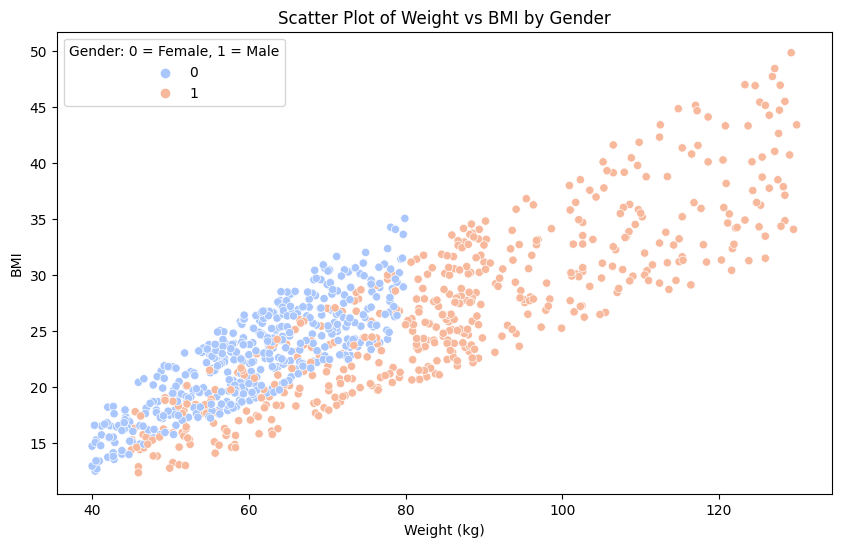

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Weight vs BMI, colored by Gender_Encoded
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Weight (kg)', y='BMI', hue='Gender_Encoded', palette='coolwarm')
plt.title('Scatter Plot of Weight vs BMI by Gender')
plt.xlabel('Weight (kg)')
plt.ylabel('BMI')
plt.legend(title='Gender: 0 = Female, 1 = Male')
plt.show()


##  Correlation Heatmap

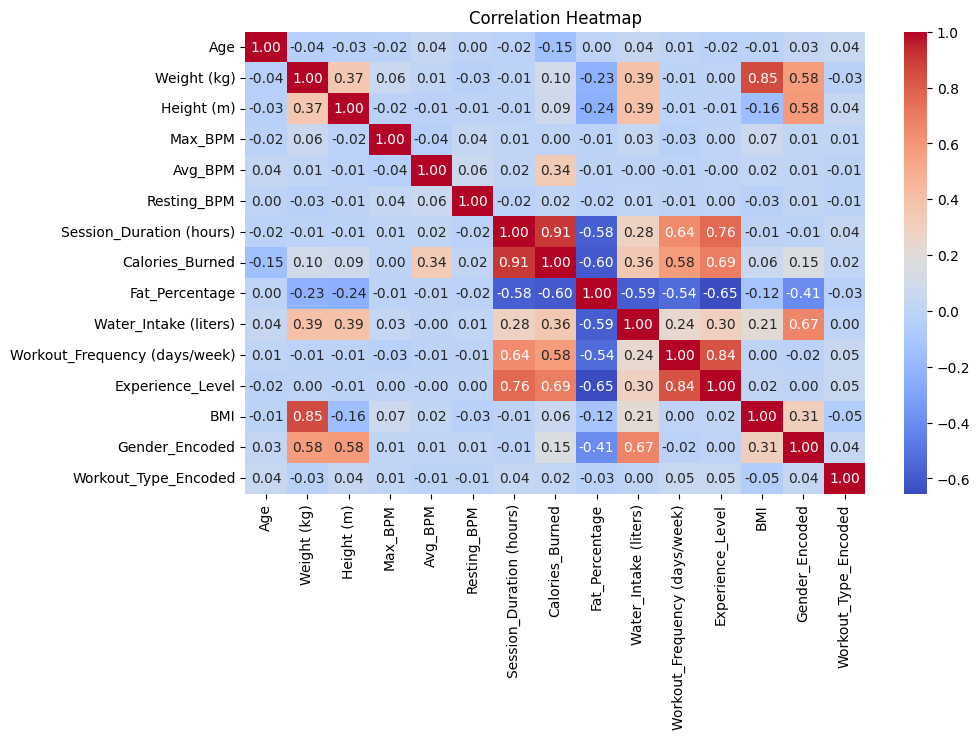

In [6]:


# Compute the correlation matrix
corr = df_new.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Pairplot (Scatterplot Matrix)

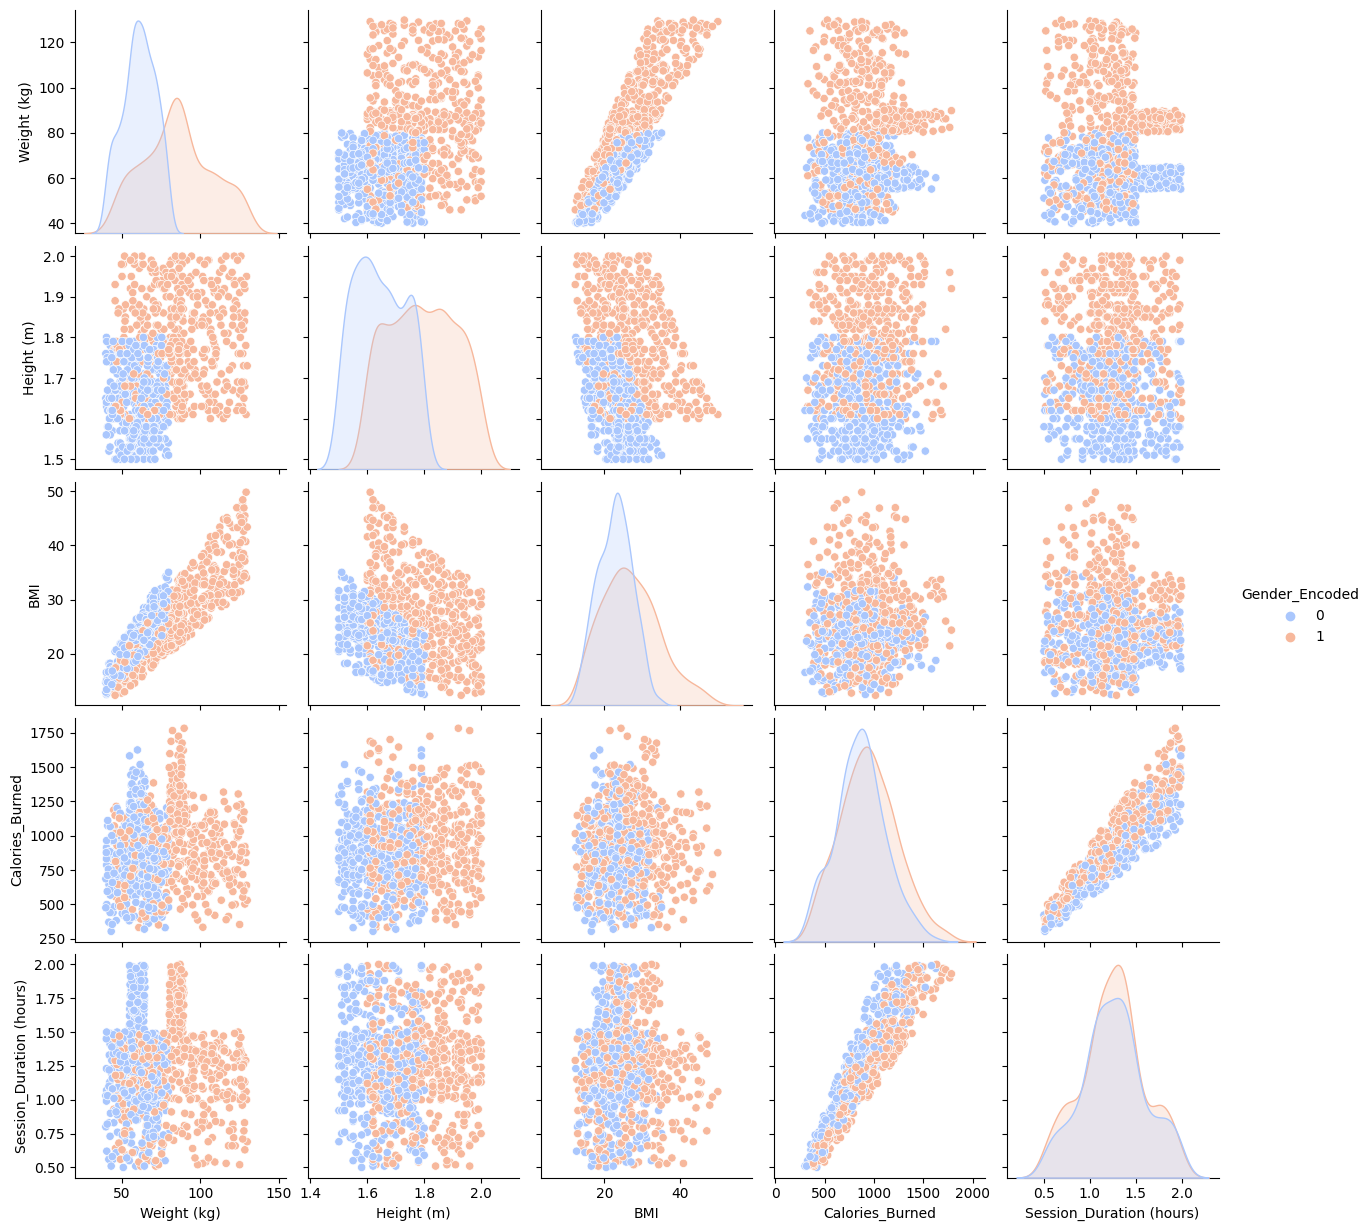

In [7]:
# Use Gender_Encoded instead of Gender for the hue parameter
sns.pairplot(df_new[['Weight (kg)', 'Height (m)', 'BMI', 'Calories_Burned', 'Session_Duration (hours)', 'Gender_Encoded']], hue='Gender_Encoded', palette='coolwarm')
plt.show()


## Boxplot of Calories Burned by Workout Type

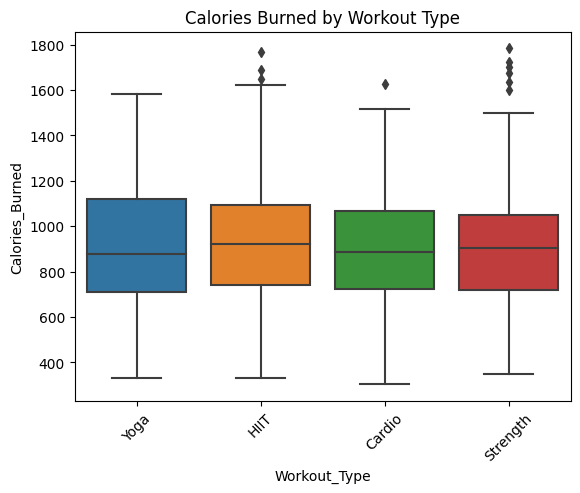

In [8]:
sns.boxplot(x='Workout_Type', y='Calories_Burned', data=df)
plt.title('Calories Burned by Workout Type')
plt.xticks(rotation=45)
plt.show()


## Violin Plot of Fat Percentage by Gender and Experience Level

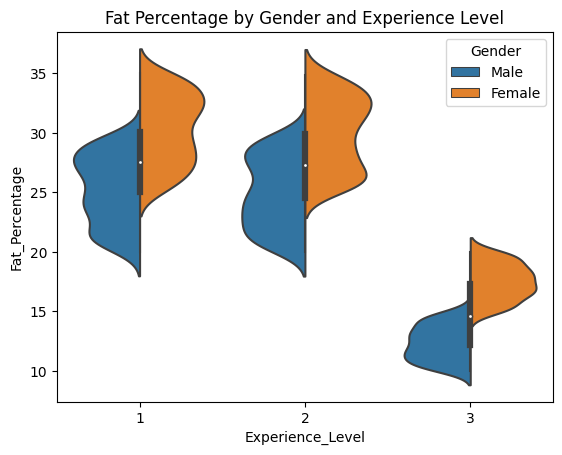

In [9]:
sns.violinplot(x='Experience_Level', y='Fat_Percentage', hue='Gender', data=df, split=True)
plt.title('Fat Percentage by Gender and Experience Level')
plt.show()


##  Jointplot of Max BPM vs Calories Burned

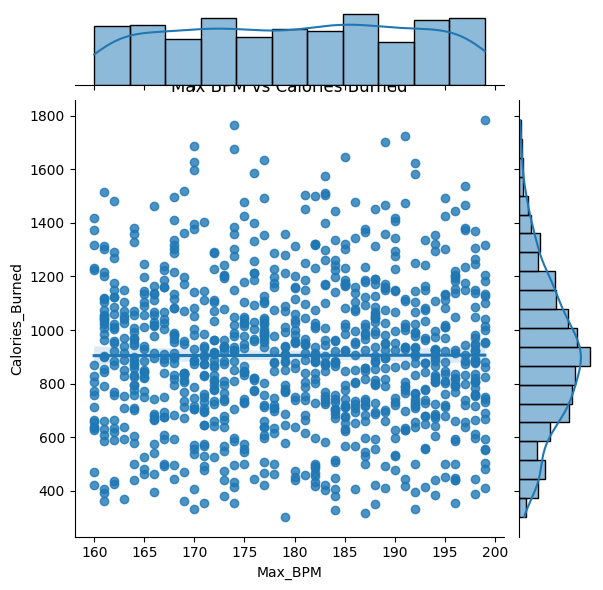

In [10]:
sns.jointplot(x='Max_BPM', y='Calories_Burned', data=df, kind='reg')
plt.title('Max BPM vs Calories Burned')
plt.show()


## Bar Plot of Workout Frequency by Experience Level

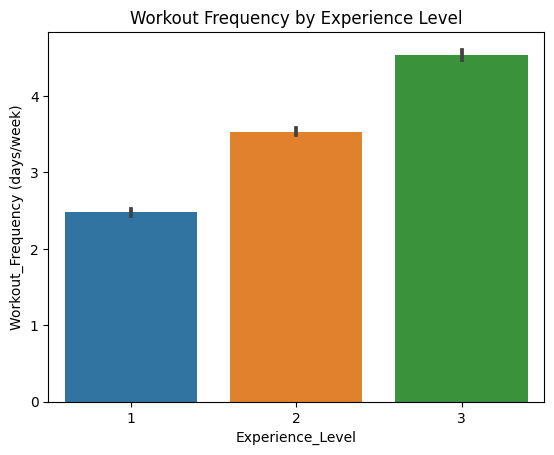

In [11]:
sns.barplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=df)
plt.title('Workout Frequency by Experience Level')
plt.show()


## FacetGrid of BMI vs Weight by Gender

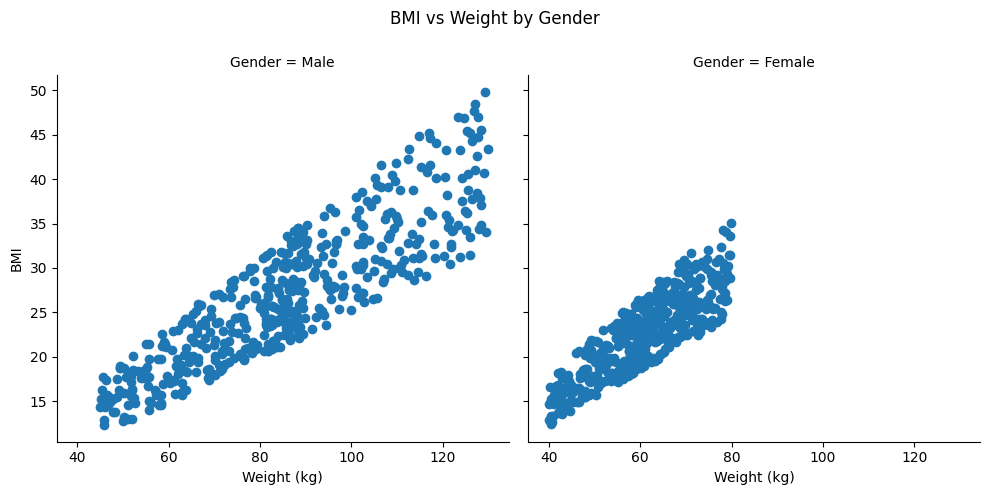

In [12]:
g = sns.FacetGrid(df, col="Gender", height=5)
g.map(plt.scatter, 'Weight (kg)', 'BMI')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('BMI vs Weight by Gender')
plt.show()


##  Stacked Bar Plot of Workout Type Distribution by Gender

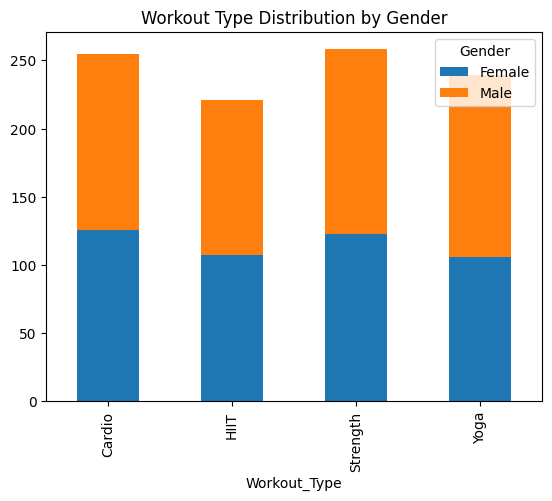

In [13]:
pd.crosstab(df['Workout_Type'], df['Gender']).plot(kind='bar', stacked=True)
plt.title('Workout Type Distribution by Gender')
plt.show()


## Calories Burned vs Session Duration with Experience Level as Color

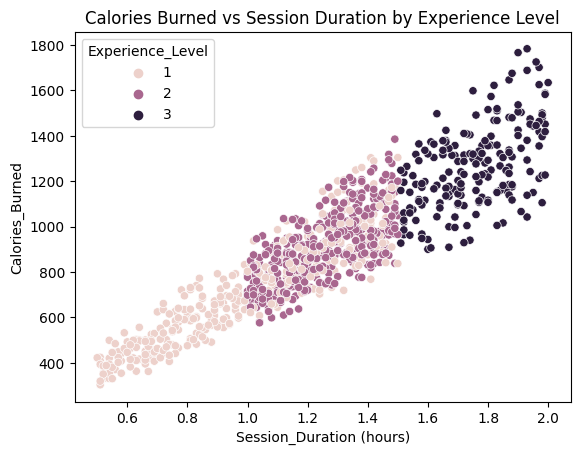

In [14]:
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', hue='Experience_Level', data=df)
plt.title('Calories Burned vs Session Duration by Experience Level')
plt.show()


##  Radar Chart for Workout Performance Metrics

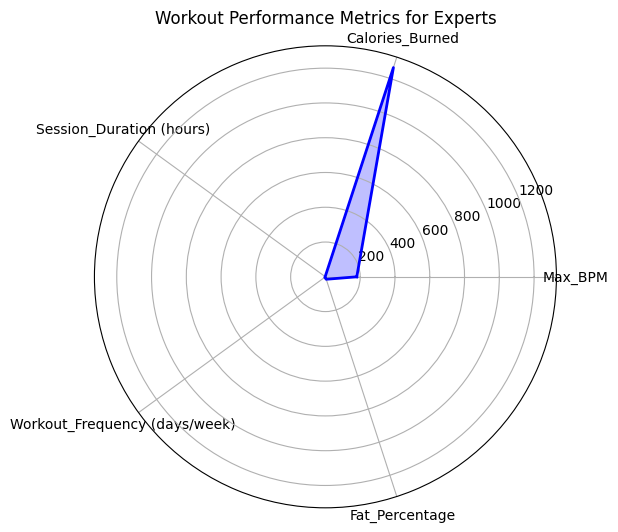

In [15]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt

# Create a radar chart for a single example
categories = ['Max_BPM', 'Calories_Burned', 'Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Fat_Percentage']
values = df[df['Experience_Level'] == 3][categories].mean().values.flatten().tolist()
values += values[:1]  # To make the plot circular

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=2)
plt.xticks(angles[:-1], categories)
plt.title('Workout Performance Metrics for Experts')
plt.show()


## Histogram of Workout Frequency by Gender

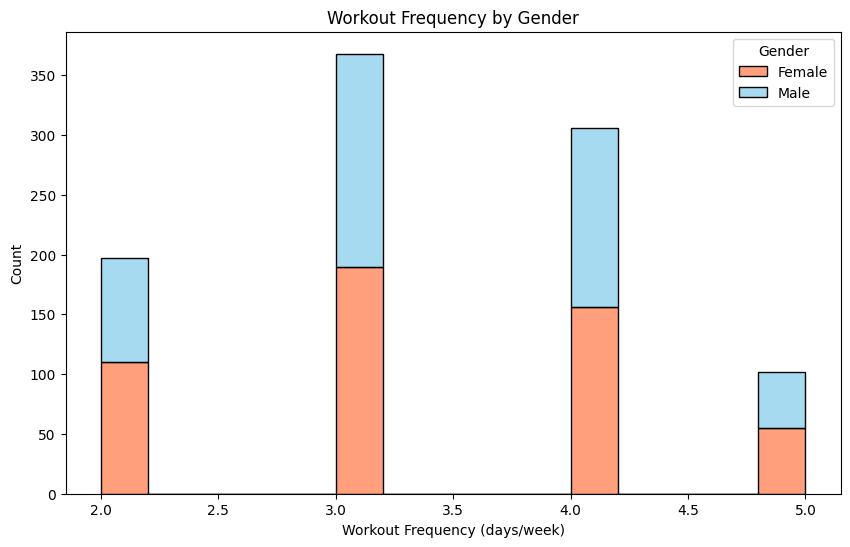

In [16]:
# Custom color palette
palette = {0: 'skyblue', 1: 'coral'}

# Histogram: Workout Frequency by Gender
plt.figure(figsize=(10, 6))
sns.histplot(data=df_new, x='Workout_Frequency (days/week)', hue='Gender_Encoded', multiple="stack", palette=palette)
plt.title('Workout Frequency by Gender')
plt.xlabel('Workout Frequency (days/week)')
plt.ylabel('Count')

# Custom legend with gender labels
plt.legend(labels=['Female', 'Male'], title='Gender')
plt.show()


## Scatter Plot of Max_BPM vs Calories Burned Colored by Workout Type

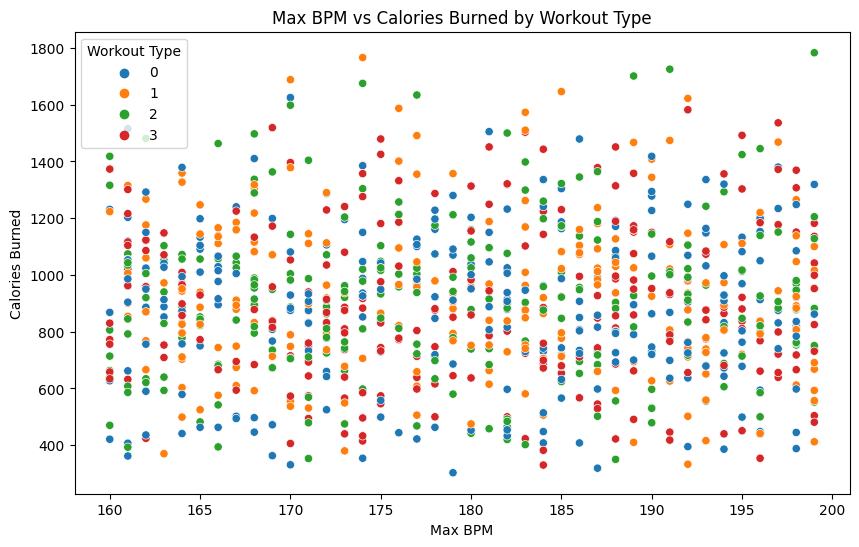

In [17]:
# Scatter plot: Max_BPM vs Calories_Burned, colored by Workout_Type_Encoded
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Max_BPM', y='Calories_Burned', hue='Workout_Type_Encoded', palette='tab10')
plt.title('Max BPM vs Calories Burned by Workout Type')
plt.xlabel('Max BPM')
plt.ylabel('Calories Burned')
plt.legend(title='Workout Type')
plt.show()
